This file is for deciding what freezing strategy to use 

From previous files, the lr for head is 0.0017378008365631102 and lr range for whole model is ((1.9054607491852948e-06)/10, (1.9054607491852948e-06)/4)
The no. of epochs for head remains const. at 3 and no. of epochs for whole model is 8 as found in prev. file
The batch size found is 16 from prev. file
The weight decay found is 1e-3
The optimizer found is RMSProp
The lr_scheduler found is OneCycleLR

I will be doing these experiments

1. Train only head

2. Head->unfreeze all 

3. Train entire model from beginning

So here goes our first experimnet in which i will be traing only head

In [1]:
import pandas as pd
import regex as re
from fastai.vision.all import *

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [3]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Names'][class_id]

In [4]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [5]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [6]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [7]:
set_seed(42, reproducible = True)

In [8]:
dls_7_1 = signs.dataloaders(path, bs = 16)

In [10]:
model_7_1 = vision_learner(dls_7_1, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_1.fit_one_cycle(11, lr_head, wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.637769,0.533068,0.124096,00:25
1,0.454536,0.135991,0.042169,00:24
2,0.241018,0.050466,0.016867,00:24
3,0.104049,0.034555,0.014458,00:25
4,0.070282,0.008179,0.001205,00:25
5,0.044473,0.002915,0.001205,00:25
6,0.024559,0.000366,0.000000,00:25
7,0.020101,0.000571,0.000000,00:26
8,0.012429,0.000648,0.000000,00:27
9,0.005000,0.000227,0.000000,00:26


In [11]:
set_seed(42, reproducible = True)

In [12]:
dls_7_2 = signs.dataloaders(path, bs = 16)

In [13]:
model_7_2 = vision_learner(dls_7_2, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_2.fit_one_cycle(3, lr_head, wd = 1e-3)
model_7_2.unfreeze()
model_7_2.fit_one_cycle(8, lr_max = slice(lr_whole_model/10, lr_whole_model/4), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,0.786328,0.190654,0.055422,00:21
1,0.191432,0.049008,0.015663,00:21
2,0.079777,0.022944,0.003614,00:21


epoch,train_loss,valid_loss,error_rate,time
0,0.083987,0.024915,0.008434,00:32
1,0.079429,0.022036,0.003614,00:34
2,0.065454,0.019609,0.003614,00:28
3,0.070738,0.021263,0.006024,00:28
4,0.061640,0.019952,0.004819,00:30
5,0.060167,0.017512,0.004819,00:29
6,0.066579,0.019838,0.004819,00:30
7,0.066935,0.018061,0.002410,00:34


In [14]:
set_seed(42, reproducible = True)

In [15]:
dls_7_3 = signs.dataloaders(path, bs = 16)

In [ ]:
model_7_3 = vision_learner(dls_7_3, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_3.unfreeze()
model_7_3.fit_one_cycle(11, lr_max = slice(lr_whole_model/10, lr_whole_model/4), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,5.852031,4.754595,0.983133,00:33
1,5.679916,4.685046,0.973494,00:41
2,5.608136,4.477447,0.946988,00:41
3,5.501852,4.314431,0.926506,00:41
4,5.287176,4.216847,0.913253,00:32
5,5.171170,4.054299,0.886747,00:28
6,5.049512,3.965364,0.871084,00:33
7,5.049190,3.925337,0.861446,00:28
8,5.061792,3.910478,0.848193,00:29
9,4.990690,3.879674,0.838554,00:40


Ok so as lr was too high for early layers and so rerunning this experiment to conclude

In [17]:
set_seed(42, reproducible = True)

In [18]:
dls_7_4 = signs.dataloaders(path, bs = 16)

<div></div>

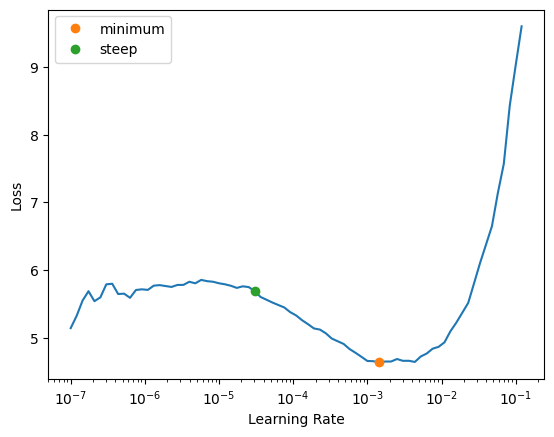

In [19]:
model_7_4 = vision_learner(dls_7_4, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_4.unfreeze()
lr_min, lr_steep = model_7_4.lr_find(suggest_funcs=(minimum,steep))

In [20]:
lr_min, lr_steep

(0.00014454397605732084, 3.0199516913853586e-05)

In [21]:
model_7_3 = vision_learner(dls_7_3, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_3.unfreeze()
model_7_3.fit_one_cycle(11, lr_max = slice(lr_steep/10, lr_steep), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,5.220664,3.849616,0.881928,00:34
1,3.355618,1.759645,0.393976,00:35
2,1.574232,0.777874,0.172289,00:35
3,0.939406,0.408589,0.086747,00:34
4,0.649173,0.257216,0.061446,00:33
5,0.424437,0.160157,0.033735,00:34
6,0.332940,0.105755,0.025301,00:34
7,0.253330,0.088145,0.020482,00:34
8,0.195868,0.077189,0.019277,00:34
9,0.213763,0.075807,0.019277,00:34


In [22]:
df2 = pd.read_csv(r'D:\Traffic\test_csv.csv')

In [24]:
fname = Path(r'D:\Traffic\traffic_Data_processed\TEST\057_0002_j.png')
class_name = re.findall(r'(\d+)_.*\.png$', fname.name)
class_id = int(class_name[0])
real_id = int(df2['New'][class_id])
real_id

54

In [25]:
def label_function_test(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    real_id = int(df2['New'][class_id])
    return df['Names'][real_id]

In [26]:
signs_test = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = None,
                  get_y = label_function_test,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [27]:
path_test = Path(r'D:\Traffic\traffic_Data_processed\TEST')

In [28]:
dls_test = signs_test.dataloaders(path_test)

In [33]:
losses_dict_1 = dict()

In [34]:
losses_dict_2 = dict()

In [35]:
for x in range(len(dls_test)):
    dl = dls_test[x]
    _, _, losses_dict_1[x] = model_7_1.get_preds(dl = dl,
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           reorder = False
                                           )

In [36]:
for x in range(len(dls_test)):
    dl = dls_test[x]
    _, _, losses_dict_2[x] = model_7_2.get_preds(dl = dl,
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           reorder = False
                                           )

In [37]:
def final_loss(losses):
    summation = 0
    total = 0
    for x in range(len(losses)):
        total += len(losses[x])
        for y in range(len(losses[x])):
            summation += losses[x][y]
            
    return float(summation)/float(total)

In [38]:
final_loss(losses_dict_1)

9.221841305165496

In [40]:
final_loss(losses_dict_2)

6.5566278914869605

In [41]:
interp1 = ClassificationInterpretation.from_learner(model_7_1, dl = dls_test[0])

In [42]:
interp2 = ClassificationInterpretation.from_learner(model_7_2, dl = dls_test[0])

In [43]:
interp1.print_classification_report()

                              precision    recall  f1-score   support

           Bicycles crossing       0.39      0.70      0.50        30
           Children crossing       0.94      0.76      0.84        21
                Danger Ahead       1.00      0.57      0.73         7
 Dangerous curve to the left       1.00      0.27      0.42        30
Dangerous curve to the right       1.00      0.54      0.70        24
                Dont Go Left       1.00      0.59      0.74        99
       Dont Go Left or Right       1.00      0.87      0.93        15
               Dont Go Right       1.00      0.65      0.79        74
            Dont Go straight       1.00      0.89      0.94        47
    Dont Go straight or left       0.00      0.00      0.00        13
     Dont overtake from Left       0.00      0.00      0.00        10
                      Fences       0.00      0.00      0.00        16
                    Give Way       0.00      0.00      0.00         2
                   

c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [44]:
interp2.print_classification_report()

                              precision    recall  f1-score   support

           Bicycles crossing       0.17      0.57      0.27        30
           Children crossing       1.00      0.43      0.60        21
                Danger Ahead       1.00      1.00      1.00         7
 Dangerous curve to the left       0.59      0.33      0.43        30
Dangerous curve to the right       0.62      0.33      0.43        24
                Dont Go Left       0.95      0.77      0.85        99
       Dont Go Left or Right       1.00      0.80      0.89        15
               Dont Go Right       0.95      0.53      0.68        74
            Dont Go straight       0.94      1.00      0.97        47
    Dont Go straight or left       0.00      0.00      0.00        13
     Dont overtake from Left       0.00      0.00      0.00        10
                      Fences       0.00      0.00      0.00        16
                    Give Way       0.00      0.00      0.00         2
                   

c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _